# Image generation with Flux.1 and OpenVINO

Flux is a AI image generation model developed by [Black Forest Labs](https://blackforestlabs.ai/our-team/). It represents a significant advancement in AI-generated art, utilizing a hybrid architecture of [multimodal](https://arxiv.org/abs/2403.03206) and [parallel](https://arxiv.org/abs/2302.05442) [diffusion transformer](https://arxiv.org/abs/2212.09748) blocks and scaled to 12B parameter. The model offers state-of-the-art performance image generation with top of the line prompt following, visual quality, image detail and output diversity. More details about model can be found in [blog post](https://blackforestlabs.ai/announcing-black-forest-labs/) and [original repo](https://github.com/black-forest-labs/flux).

<img src="https://raw.githubusercontent.com/black-forest-labs/flux/main/assets/grid.jpg" width="1024" height="800"> 

In this tutorial we consider how to convert and optimize Flux.1 model using OpenVINO.

>**Note**: Some demonstrated models can require at least 32GB RAM for conversion and running.

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Select model](#Select-model)
- [Convert model with OpenVINO](#Convert-model-with-OpenVINO)
  - [Convert model using Optimum Intel](#Convert-model-using-Optimum-Intel)
  - [Compress model weights](#Compress-model-weights)
  - [Use optimized models provided on HuggingFace Hub](#use-optimized-models-provided-on-huggingface-hub)
- [Run OpenVINO model inference](#Run-OpenVINO-model-inference)
- [Interactive demo](#Interactive-demo)



<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/flux.1-image-generation/flux.1-image-generation.ipynb" />

### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

## Prerequisites
[back to top ⬆️](#Table-of-contents:)

In [1]:
%pip install -q "gradio>=4.19,<6" "torch==2.8" "transformers==4.57.6" "nncf>=2.15.0" "diffusers>=0.31.0,<0.38.0" "opencv-python" "pillow" "peft>=0.15.0" "optimum" --extra-index-url https://download.pytorch.org/whl/cpu
%pip install -q "sentencepiece" "protobuf"
%pip install -q "https://codeload.github.com/huggingface/optimum-intel/tar.gz/HEAD"
%pip install -qU "openvino>=2025.4.0" "openvino_genai>=2025.4" "openvino_tokenizers>=2025.4"

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [Errno 28] No space left on device



Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [2]:
import requests
from pathlib import Path

if not Path("cmd_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/cmd_helper.py")
    open("cmd_helper.py", "w").write(r.text)

if not Path("gradio_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/notebooks/flux.1-image-generation/gradio_helper.py")
    open("gradio_helper.py", "w").write(r.text)

if not Path("notebook_utils.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py")
    open("notebook_utils.py", "w").write(r.text)

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("flux.1-image-generation.ipynb")

## Select model
[back to top ⬆️](#Table-of-contents:)

To strike a balance between accessibility and model capabilities, FLUX.1 comes in two variants: FLUX.1-Krea-dev and FLUX.1-schnell: 
* **FLUX.1-Krea-dev**: FLUX.1 Krea [dev] is a 12 billion parameter rectified flow transformer capable of generating images from text descriptions.
* **FLUX.1-schnell**: the fastest model from Flux family is tailored for local development and personal use. FLUX.1-schnell is openly available under an Apache2.0 license. Weights are available on [HuggingFace](https://huggingface.co/black-forest-labs/FLUX.1-schnell).

![family.png](https://github.com/user-attachments/assets/c7f9df6b-cff3-4d33-98d7-1bb400b2861c)

Be default, we will use FLUX.1-schnell model.

In [3]:
import ipywidgets as widgets

model_ids = ["black-forest-labs/FLUX.1-schnell", "black-forest-labs/FLUX.1-Krea-dev"]

model_selector = widgets.Dropdown(
    options=model_ids,
    default=model_ids[0],
    description="Model:",
)


model_selector

Dropdown(description='Model:', options=('black-forest-labs/FLUX.1-schnell', 'black-forest-labs/FLUX.1-Krea-dev…

## Convert model with OpenVINO
[back to top ⬆️](#Table-of-contents:)

Starting from 2023.0 release, OpenVINO supports PyTorch models directly via Model Conversion API. `ov.convert_model` function accepts instance of PyTorch model and example inputs for tracing and returns object of `ov.Model` class, ready to use or save on disk using `ov.save_model` function. 


The pipeline consists of four important parts:

* Clip and T5 Text Encoders to create condition to generate an image from a text prompt.
* Transformer for step-by-step denoising latent image representation.
* Autoencoder (VAE) for decoding latent space to image.
  
### Convert model using Optimum Intel
[back to top ⬆️](#Table-of-contents:)

For convenience, we will use OpenVINO integration with HuggingFace Optimum. 🤗 [Optimum Intel](https://huggingface.co/docs/optimum/intel/index) is the interface between the 🤗 Transformers and Diffusers libraries and the different tools and libraries provided by Intel to accelerate end-to-end pipelines on Intel architectures.

Among other use cases, Optimum Intel provides a simple interface to optimize your Transformers and Diffusers models, convert them to the OpenVINO Intermediate Representation (IR) format and run inference using OpenVINO Runtime. `optimum-cli` provides command line interface for model conversion and optimization. 

General command format:

```bash
optimum-cli export openvino --model <model_id_or_path> --task <task> <output_dir>
```

where task is task to export the model for, if not specified, the task will be auto-inferred based on the model. You can find a mapping between tasks and model classes in Optimum TaskManager [documentation](https://huggingface.co/docs/optimum/exporters/task_manager). Additionally, you can specify weights compression using `--weight-format` argument with one of following options: `fp32`, `fp16`, `int8` and `int4`. Fro int8 and int4 [nncf](https://github.com/openvinotoolkit/nncf) will be used for  weight compression. More details about model export provided in [Optimum Intel documentation](https://huggingface.co/docs/optimum/intel/openvino/export#export-your-model).

### Compress model weights
[back to top ⬆️](#Table-of-contents:)

For reducing model memory consumption we will use weights compression. The [Weights Compression](https://docs.openvino.ai/2024/openvino-workflow/model-optimization-guide/weight-compression.html) algorithm is aimed at compressing the weights of the models and can be used to optimize the model footprint and performance of large models where the size of weights is relatively larger than the size of activations, for example, Large Language Models (LLM). Compared to INT8 compression, INT4 compression improves performance even more, but introduces a minor drop in prediction quality. We will use [NNCF](https://github.com/openvinotoolkit/nncf) integration to `optimum-cli` tool for weight compression.

### Use optimized models provided on HuggingFace Hub
[back to top ⬆️](#Table-of-contents:)

For quick start, OpenVINO provides [collection](https://huggingface.co/collections/OpenVINO/image-generation-67697d9952fb1eee4a252aa8) of optimized models that are ready to use with OpenVINO GenAI. You can download them using following command:

```bash
huggingface-cli download <model_id> --local-dir <output_dir>
```


In [4]:
use_preconverted = widgets.Checkbox(value="schnell" in model_selector.value, description="Use preconverted model", disable=False)

to_compress = widgets.Checkbox(
    value=True,
    description="Weight compression",
    disabled=False,
)

visible_widgets = [to_compress]

if "schnell" in model_selector.value:
    visible_widgets.append(use_preconverted)

options = widgets.VBox(visible_widgets)

options

In [5]:
from pathlib import Path

model_id = model_selector.value

model_base_dir = Path(model_id.split("/")[-1])
additional_args = {}

if to_compress.value:
    model_dir = model_base_dir / "INT4"
    additional_args.update({"weight-format": "int4", "group-size": "64", "ratio": "1.0"})
else:
    model_dir = model_base_dir / "FP16"
    additional_args.update({"weight-format": "fp16"})

In [6]:
from cmd_helper import optimum_cli
from huggingface_hub import snapshot_download

if not model_dir.exists():
    if not use_preconverted.value:
        optimum_cli(model_id, model_dir, additional_args=additional_args)
    else:
        ov_model_id = f"OpenVINO/{model_id.split('/')[-1]}-{model_dir.name.lower()}-ov"
        snapshot_download(repo_id=ov_model_id, local_dir=model_dir)

Fetching 35 files:   0%|          | 0/35 [00:00<?, ?it/s]

.gitattributes: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

scheduler_config.json: 0.00B [00:00, ?B/s]

openvino_model.xml: 0.00B [00:00, ?B/s]

...

openvino_model.bin:   0%|          | 0.00/6.41G [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

openvino_model.bin:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

openvino_model.xml: 0.00B [00:00, ?B/s]

openvino_model.bin:   0%|          | 0.00/34.0M [00:00<?, ?B/s]

## Run OpenVINO GenAI model inference
[back to top ⬆️](#Table-of-contents:)

Select device from dropdown list for running inference using OpenVINO.

In [7]:
from notebook_utils import device_widget

device = device_widget(default="CPU", exclude=["NPU"])
device

Dropdown(description='Device:', options=('CPU', 'GPU', 'AUTO'), value='CPU')

In [8]:
import ipywidgets as widgets

model_available = (model_base_dir / "INT4").is_dir()
use_quantized_models = widgets.Checkbox(
    value=model_available,
    description="Use compressed models",
    disabled=not model_available,
)

use_quantized_models

Checkbox(value=True, description='Use compressed models')

`openvino_genai.Text2ImagePipeline` represents inference pipeline for text-to-image generation. For creation pipeline instance, you should provide directory with converted to OpenVINO model and inference device.

In [9]:
import openvino_genai as ov_genai

model_dir = model_base_dir / "INT4" if use_quantized_models.value else model_base_dir / "FP16"

ov_pipe = ov_genai.Text2ImagePipeline(model_dir, device=device.value)

Model: OV Tokenizer
  NETWORK_NAME: tokenizer
  OPTIMAL_NUMBER_OF_INFER_REQUESTS: 1
  NUM_STREAMS: 1
  INFERENCE_NUM_THREADS: 32
  PERF_COUNT: NO
  INFERENCE_PRECISION_HINT: bf16
  PERFORMANCE_HINT: LATENCY
  EXECUTION_MODE_HINT: PERFORMANCE
  PERFORMANCE_HINT_NUM_REQUESTS: 0
  ENABLE_CPU_PINNING: YES
  ENABLE_CPU_RESERVATION: NO
  SCHEDULING_CORE_TYPE: ANY_CORE
  MODEL_DISTRIBUTION_POLICY: 
  ENABLE_HYPER_THREADING: NO
  EXECUTION_DEVICES: CPU
  CPU_DENORMALS_OPTIMIZATION: NO
  LOG_LEVEL: LOG_NONE
  CPU_SPARSE_WEIGHTS_DECOMPRESSION_RATE: 1
  ENABLE_TENSOR_PARALLEL: NO
  TBB_PARTITIONER: STATIC
  DYNAMIC_QUANTIZATION_GROUP_SIZE: 32
  KV_CACHE_PRECISION: u8
  KEY_CACHE_PRECISION: u8
  VALUE_CACHE_PRECISION: u8
  KEY_CACHE_GROUP_SIZE: 0
  VALUE_CACHE_GROUP_SIZE: 0
  RUNTIME_REQUIREMENTS: meta=1.0;ov=2026.4.1;isa=Intel AVX-512 with Intel DL Boost and bfloat16 support
EXECUTION_DEVICES:
 CPU: AMD EPYC 9334 32-Core Processor                
Model: OV Detokenizer
  NETWORK_NAME: detokenizer


 PERFORMANCE_HINT: LATENCY
  EXECUTION_MODE_HINT: PERFORMANCE
  PERFORMANCE_HINT_NUM_REQUESTS: 0
  ENABLE_CPU_PINNING: YES
  ENABLE_CPU_RESERVATION: NO
  SCHEDULING_CORE_TYPE: ANY_CORE
  MODEL_DISTRIBUTION_POLICY: 
  ENABLE_HYPER_THREADING: NO
  EXECUTION_DEVICES: CPU
  CPU_DENORMALS_OPTIMIZATION: NO
  LOG_LEVEL: LOG_NONE
  CPU_SPARSE_WEIGHTS_DECOMPRESSION_RATE: 1
  ENABLE_TENSOR_PARALLEL: NO
  TBB_PARTITIONER: STATIC
  DYNAMIC_QUANTIZATION_GROUP_SIZE: 32
  KV_CACHE_PRECISION: u8
  KEY_CACHE_PRECISION: u8
  VALUE_CACHE_PRECISION: u8
  KEY_CACHE_GROUP_SIZE: 0
  VALUE_CACHE_GROUP_SIZE: 0
  RUNTIME_REQUIREMENTS: meta=1.0;ov=2026.4.1;isa=Intel AVX-512 with Intel DL Boost and bfloat16 support
EXECUTION_DEVICES:
 CPU: AMD EPYC 9334 32-Core Processor                
Model: OV Detokenizer
  NETWORK_NAME: detokenizer
  OPTIMAL_NUMBER_OF_INFER_REQUESTS: 1
  NUM_STREAMS: 1
  INFERENCE_NUM_THREADS: 32
  PERF_COUNT: NO
  INFERENCE_PRECISION_HINT: bf16
  PERFORMANCE_HINT: LATENCY
  EXECUTION_MODE_HI

Now, you can define a text prompt and other pipeline settings for image generation and run inference pipeline.

> **Note**: Consider increasing `num_inference_steps` to get more precise results, but higher value will take longer time to process.

In [10]:
prompt = "A cat holding a sign that says hello OpenVINO"
height = 256
width = 256
seed = 42
num_inference_steps = 4

print("Pipeline settings")
print(f"Input text: {prompt}")
print(f"Image size: {height} x {width}")
print(f"Seed: {seed}")
print(f"Number of steps: {num_inference_steps}")

Pipeline settings
Input text: A cat holding a sign that says hello OpenVINO
Image size: 256 x 256
Seed: 42
Number of steps: 4


  0%|          | 0/4 [00:00<?, ?it/s]

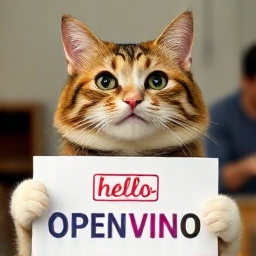

In [11]:
from PIL import Image
from tqdm.notebook import tqdm
import sys

random_generator = ov_genai.TorchGenerator(seed)
pbar = tqdm(total=num_inference_steps)


def callback(step, num_steps, latent):
    if num_steps != pbar.total:
        pbar.reset(num_steps)
    pbar.update(1)
    sys.stdout.flush()
    return False


result = ov_pipe.generate(prompt, num_inference_steps=num_inference_steps, generator=random_generator, callback=callback, height=height, width=width)

pbar.close()

final_image = Image.fromarray(result.data[0])

final_image

## Interactive demo
[back to top ⬆️](#Table-of-contents:)